# Human IN Loop

In [20]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [21]:
from langchain_groq import ChatGroq
model = ChatGroq(model="openai/gpt-oss-120b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.6', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000283A98011D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000283A9801BD0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [22]:
from typing import Annotated
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.types import Command, interrupt

class State(TypedDict):
    messages: Annotated[list,add_messages]

graph_builder = StateGraph(State)

    

In [23]:
@tool
def human_assist(query:str)->str:
    """request assistence from human"""
    human_res = interrupt({"query":query})
    return human_res

tool = TavilySearch(max_result=2)
tools = [tool,human_assist]
llm_with_tools = model.bind_tools(tools)


In [24]:
def chatbot(State: State):
    message = llm_with_tools.invoke(State["messages"])
    # Because we will be interrupting during tool execution,
    # we disable parallel tool calling to avoid repeating any
    # tool invocations when we resume.
    return {"messages" : [message]}

graph_builder.add_node('chatbot',chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)

#edges
# strt se chatbot then chatbot se conditional i.e tools or end then tools se chatbot ki taraf
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools","chatbot")


In [25]:
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)

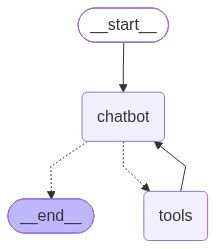

In [26]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

^^^ dashed edges means conditional

In [27]:
user_input = "I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": user_input},
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assist (fc_6a0b5e7e-19c3-45a5-80f9-623a004ce327)
 Call ID: fc_6a0b5e7e-19c3-45a5-80f9-623a004ce327
  Args:
    query: User is requesting expert guidance and assistance for building an AI agent. Please provide detailed support.
================================== Ai Message ==================================
Tool Calls:
  human_assist (fc_6a0b5e7e-19c3-45a5-80f9-623a004ce327)
 Call ID: fc_6a0b5e7e-19c3-45a5-80f9-623a004ce327
  Args:
    query: User is requesting expert guidance and assistance for building an AI agent. Please provide detailed support.


In [28]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

#Command LangGraph mein graph ko instruction dene ke liye use hota hai.
#Human ne jo answer/input diya hai, 
#us answer ke saath paused LangGraph workflow ko resume karo.
human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assist (fc_6a0b5e7e-19c3-45a5-80f9-623a004ce327)
 Call ID: fc_6a0b5e7e-19c3-45a5-80f9-623a004ce327
  Args:
    query: User is requesting expert guidance and assistance for building an AI agent. Please provide detailed support.
================================= Tool Message =================================
Name: human_assist

{"data": "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents."}
================================== Ai Message ==================================

Absolutely! Building a robust AI agent can feel overwhelming at first, but breaking the process into clear, manageable steps makes it much more approachable. Below is a practical roadmap, along with tools, patterns, and resources that will help you design, implement, and iterate on a production‑ready agent.

---